# Статистика игроков FIFA

### **Модуль 1. Разведочный анализ данных, описание датасета, важность признаков**

In [112]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as  plt
%matplotlib inline

In [113]:
fifa = pd.read_csv('FIFA_raw_data.xls', low_memory=False)
pd.set_option('display.max_columns', None)
fifa.head()

,photoUrl,LongName,playerUrl,Nationality,Positions,Name,Age,↓OVA,POT,Team & Contract,ID,Height,Weight,foot,BOV,BP,Growth,Joined,Loan Date End,Value,Wage,Release Clause,Attacking,Crossing,Finishing,Heading Accuracy,Short Passing,Volleys,Skill,Dribbling,Curve,FK Accuracy,Long Passing,Ball Control,Movement,Acceleration,Sprint Speed,Agility,Reactions,Balance,Power,Shot Power,Jumping,Stamina,Strength,Long Shots,Mentality,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Defending,Marking,Standing Tackle,Sliding Tackle,Goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total Stats,Base Stats,W/F,SM,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Hits
0,https://cdn.sofifa.com/players/158/023/21_60.png,Lionel Messi,http://sofifa.com/player/158023/lionel-messi/2...,Argentina,RW ST CF,L. Messi,33,93,93,\n\n\n\nFC Barcelona\n2004 ~ 2021\n\n,158023,"5'7""",159lbs,Left,93,RW,0,"Jul 1, 2004",NaN,€67.5M,€560K,€138.4M,429,85,95,70,91,88,470,96,93,94,91,96,451,91,80,91,94,95,389,86,68,72,69,94,347,44,40,93,95,75,96,91,32,35,24,54,6,11,15,14,8,2231,466,4 ★,4★,Medium,Low,5 ★,85,92,91,95,38,65,\n372
1,https://cdn.sofifa.com/players/020/801/21_60.png,C. Ronaldo dos Santos Aveiro,http://sofifa.com/player/20801/c-ronaldo-dos-s...,Portugal,ST LW,Cristiano Ronaldo,35,92,92,\n\n\n\nJuventus\n2018 ~ 2022\n\n,20801,"6'2""",183lbs,Right,92,ST,0,"Jul 10, 2018",NaN,€46M,€220K,€75.9M,437,84,95,90,82,86,414,88,81,76,77,92,431,87,91,87,95,71,444,94,95,84,78,93,353,63,29,95,82,84,95,84,28,32,24,58,7,11,15,14,11,2221,464,4 ★,5★,High,Low,5 ★,89,93,81,89,35,77,\n344
2,https://cdn.sofifa.com/players/200/389/21_60.png,Jan Oblak,http://sofifa.com/player/200389/jan-oblak/210005/,Slovenia,GK,J. Oblak,27,91,93,\n\n\n\nAtlético Madrid\n2014 ~ 2023\n\n,200389,"6'2""",192lbs,Right,91,GK,2,"Jul 16, 2014",NaN,€75M,€125K,€159.4M,95,13,11,15,43,13,109,12,13,14,40,30,307,43,60,67,88,49,268,59,78,41,78,12,140,34,19,11,65,11,68,57,27,12,18,437,87,92,78,90,90,1413,489,3 ★,1★,Medium,Medium,3 ★,87,92,78,90,52,90,\n86
3,https://cdn.sofifa.com/players/192/985/21_60.png,Kevin De Bruyne,http://sofifa.com/player/192985/kevin-de-bruyn...,Belgium,CAM CM,K. De Bruyne,29,91,91,\n\n\n\nManchester City\n2015 ~ 2023\n\n,192985,"5'11""",154lbs,Right,91,CAM,0,"Aug 30, 2015",NaN,€87M,€370K,€161M,407,94,82,55,94,82,441,88,85,83,93,92,398,77,76,78,91,76,408,91,63,89,74,91,408,76,66,88,94,84,91,186,68,65,53,56,15,13,5,10,13,2304,485,5 ★,4★,High,High,4 ★,76,86,93,88,64,78,\n163
4,https://cdn.sofifa.com/players/190/871/21_60.png,Neymar da Silva Santos Jr.,http://sofifa.com/player/190871/neymar-da-silv...,Brazil,LW CAM,Neymar Jr,28,91,91,\n\n\n\nParis Saint-Germain\n2017 ~ 2022\n\n,190871,"5'9""",150lbs,Right,91,LW,0,"Aug 3, 2017",NaN,€90M,€270K,€166.5M,408,85,87,62,87,87,448,95,88,89,81,95,453,94,89,96,91,83,357,80,62,81,50,84,356,51,36,87,90,92,93,94,35,30,29,59,9,9,15,15,11,2175,451,5 ★,5★,High,Medium,5 ★,91,85,86,94,36,59,\n273


## Описание признаков

#### Общая информация и идентификация
- photoUrl (object): Прямая ссылка на фотографию игрока на сайте sofifa.com.
- LongName (object): Полное имя игрока.
- playerUrl (object): Прямая ссылка на страницу игрока на сайте sofifa.com.
- Nationality (object): Гражданство игрока.
- Positions (object): Позиции на поле, которые может занимать игрок (например, ST - нападающий, CM - центральный полузащитник). Сокращения соответствуют стандартным позициям в FIFA.
- Name (object): Краткое имя или псевдоним игрока.
- ID (int64): Уникальный идентификационный номер игрока в базе данных FIFA.

#### Контрактная и биографическая информация
- Age (int64): Возраст игрока (на момент создания данных).
- ↓OVA (int64): Общий рейтинг игрока (Overall Rating). Это суммарная оценка мастерства игрока. Стрелка вниз (↓) может быть частью названия столбца, указывая на сортировку.
- POT (int64): Потенциал игрока (Potential). Максимальный общий рейтинг, которого игрок может достичь в режиме карьеры.
- Team & Contract (object): Название текущего клуба игрока и срок действия контракта.
- Height (object): Рост игрока в футах и дюймах (например, 5'7").
- Weight (object): Вес игрока в фунтах (lbs).
- foot (object): Предпочтительная рабочая нога (Left, Right).
- BOV (int64): Базовая стоимость (Base Overall Value). Вероятно, начальный или минимальный общий рейтинг.
- BP (object): Базовая позиция (Best Position). Позиция, на которой игрок показывает свой наилучший общий рейтинг.
- Growth (int64): Потенциальный рост рейтинга (POT - ↓OVA). Показывает, насколько игрок может прогрессировать.
- Joined (object): Дата присоединения игрока к текущему клубу.
- Loan Date End (object): Дата окончания аренды (если игрок находится в аренде). Для игроков, не в аренде, значение отсутствует.
- Value (object): Рыночная стоимость игрока в евро (€).
- Wage (object): Еженедельная заработная плата игрока в евро (€).
- Release Clause (object): Сумма отступных в контракте игрока в евро (€).

#### Навыки и атрибуты (по категориям)
Атакующие навыки (Attacking)
- Attacking (int64): Обобщенный показатель атакующих действий.
- Crossing (int64): Точность и качество подач с флангов.
- Finishing (int64): Способность точно и хладнокровно завершать голевые моменты в штрафной площади.
- Heading Accuracy (int64): Точность и сила ударов головой.
- Short Passing (int64): Точность и качество передач на короткие и средние дистанции.
- Volleys (int64): Способность сильно и точно бить по воротам слета (с полулета).

#### Технические навыки (Skill)
- Skill (int64): Обобщенный показатель технического мастерства.
- Dribbling (int64): Способность контролировать мяч и обыгрывать соперников один в один.
- Curve (int64): Способность придавать мячу сильную подкрутку при ударах и подачах.
- FK Accuracy (int64): Точность и мастерство исполнения штрафных ударов.
- Long Passing (int64): Точность и качество передач на дальние дистанции.
- Ball Control (int64): Способность принимать мяч, обрабатывать его и контролировать.

#### Движение и мобильность (Movement)
- Movement (int64): Обобщенный показатель подвижности на поле.
- Acceleration (int64): Способность быстро набирать максимальную скорость с места.
- Sprint Speed (int64): Максимальная скорость игрока в спринте.
- Agility (int64): Ловкость, способность быстро менять направление движения, сохраняя контроль над мячом и телом.
- Reactions (int64): Скорость реакции игрока на события на поле (отскок мяча, пас соперника и т.д.).
- Balance (int64): Способность удерживать равновесие и не падать при контакте с соперником или при резких движениях.

#### Физическая мощь (Power)
- Power (int64): Обобщенный показатель физической силы и мощи.
- Shot Power (int64): Сила, с которой игрок может ударить по мячу.
- Jumping (int64): Высота и эффективность прыжка для игры на втором этаже.
- Stamina (int64): Выносливость, способность сохранять высокую работоспособность на протяжении всего матча.
- Strength (int64): Физическая сила, способность продавливать соперника в единоборствах.
- Long Shots (int64): Точность и сила ударов со средней и дальней дистанции.

#### Ментальные и психологические атрибуты (Mentality)
- Mentality (int64): Обобщенный показатель ментальной устойчивости.
- Aggression (int64): Уровень агрессивности в единоборствах, стремление идти в стык.
- Interceptions (int64): Чтение игры и способность предугадывать пасы соперника для их перехвата.
- Positioning (int64): Умение находить правильную позицию на поле для атаки, получения паса или создания момента.
- Vision (int64): Способность видеть развитие атаки и отдавать острые, неочевидные пасы.
- Penalties (int64): Хладнокровие и точность при исполнении пенальти.
- Composure (int64): Способность принимать правильные решения под давлением соперника и времени.

#### Оборонительные навыки (Defending)
- Defending (int64): Обобщенный показатель оборонительных действий.
- Marking (int64): Способность плотно опекать соперника и не давать ему получить мяч.
- Standing Tackle (int64): Эффективность отбора мяча в позиционной борьбе.
- Sliding Tackle (int64): Эффективность отбора мяча в подкате.

#### Навыки вратаря (Goalkeeping)
- Goalkeeping (int64): Обобщенный показатель вратарского мастерства.
- GK Diving (int64): Способность вратаря к прыжкам и броскам за мячами в углы ворот.
- GK Handling (int64): Надежность при ловле и фиксации мяча, умение избежать рикошета.
- GK Kicking (int64): Дальность и точность ввода мяча в игру рукой или ногой.
- GK Positioning (int64): Умение вратаря выбрать правильную позицию в воротах при различных угрозах.
- GK Reflexes (int64): Скорота реакции вратаря на удары с близкого расстояния.
- 
#### Сводные и специальные атрибуты
- Total Stats (int64): Сумма всех атрибутов игрока. Может использоваться для сравнения общей "массы" навыков.
- Base Stats (int64): Базовый уровень атрибутов. Вероятно, среднее значение или иной сводный показатель.
- W/F (object): Рабочая нога (Weak Foot). Оценка того, насколько хорошо игрок владеет "слабой" ногой. Измеряется в звездах (от 1 до 5).
- SM (object): Звезды финтов (Skill Moves). Количество звезд, показывающее арсенал финтов, доступных игроку (от 1 до 5).
- A/W (object): Атакующая рабочая нагрузка (Attacking Work Rate). Склонность игрока подключаться к атакам (Low, Medium, High).
- D/W (object): Оборонительная рабочая нагрузка (Defensive Work Rate). Склонность игрока отрабатывать в обороне (Low, Medium, High).
- IR (object): Международный рейтинг (International Reputation). Условная оценка известности игрока в мире (от 1 до 5 звезд).
- PAC (int64): Сводный показатель скорости (Pace), объединяющий ускорение и скорость спринта.
- SHO (int64): Сводный показатель ударов (Shooting), объединяющий атрибуты, связанные с завершением атак.
- PAS (int64): Сводный показатель паса (Passing).
- DRI (int64): Сводный показатель дриблинга (Dribbling).
- DEF (int64): Сводный показатель защиты (Defending).
- PHY (int64): Сводный показатель физической мощи (Physicality).
- Hits (object): Количество просмотров страницы игрока на сайте sofifa.com. Может служить индикатором популярности.

Набор данных содержит подробную информацию о футболистах из игры FIFA 21. Он включает 77 характеристик, таких как возраст (Age), текущий рейтинг (OVA), потенциал (POT), стоимость (Value), зарплата (Wage), а также игровые навыки (дриблинг, точность паса и др.).

## Разведочный анализ

In [114]:
fifa.shape

(18979, 77)

In [115]:
fifa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18979 entries, 0 to 18978
Data columns (total 77 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   photoUrl          18979 non-null  object
 1   LongName          18979 non-null  object
 2   playerUrl         18979 non-null  object
 3   Nationality       18979 non-null  object
 4   Positions         18979 non-null  object
 5   Name              18979 non-null  object
 6   Age               18979 non-null  int64 
 7   ↓OVA              18979 non-null  int64 
 8   POT               18979 non-null  int64 
 9   Team & Contract   18979 non-null  object
 10  ID                18979 non-null  int64 
 11  Height            18979 non-null  object
 12  Weight            18979 non-null  object
 13  foot              18979 non-null  object
 14  BOV               18979 non-null  int64 
 15  BP                18979 non-null  object
 16  Growth            18979 non-null  int64 
 17  Joined      

In [116]:
fifa.dtypes

photoUrl            object
LongName            object
playerUrl           object
Nationality         object
Positions           object
Name                object
Age                  int64
↓OVA                 int64
POT                  int64
Team & Contract     object
ID                   int64
Height              object
Weight              object
foot                object
BOV                  int64
BP                  object
Growth               int64
Joined              object
Loan Date End       object
Value               object
Wage                object
Release Clause      object
Attacking            int64
Crossing             int64
Finishing            int64
Heading Accuracy     int64
Short Passing        int64
Volleys              int64
Skill                int64
Dribbling            int64
Curve                int64
FK Accuracy          int64
Long Passing         int64
Ball Control         int64
Movement             int64
Acceleration         int64
Sprint Speed         int64
A

## Проверка пропущенных значений

In [117]:
fifa.isna().sum()

photoUrl                0
LongName                0
playerUrl               0
Nationality             0
Positions               0
Name                    0
Age                     0
↓OVA                    0
POT                     0
Team & Contract         0
ID                      0
Height                  0
Weight                  0
foot                    0
BOV                     0
BP                      0
Growth                  0
Joined                  0
Loan Date End       17966
Value                   0
Wage                    0
Release Clause          0
Attacking               0
Crossing                0
Finishing               0
Heading Accuracy        0
Short Passing           0
Volleys                 0
Skill                   0
Dribbling               0
Curve                   0
FK Accuracy             0
Long Passing            0
Ball Control            0
Movement                0
Acceleration            0
Sprint Speed            0
Agility                 0
Reactions   

In [118]:
pd.set_option('display.max_rows', None)

In [119]:
fifa.isna().sum()

photoUrl                0
LongName                0
playerUrl               0
Nationality             0
Positions               0
Name                    0
Age                     0
↓OVA                    0
POT                     0
Team & Contract         0
ID                      0
Height                  0
Weight                  0
foot                    0
BOV                     0
BP                      0
Growth                  0
Joined                  0
Loan Date End       17966
Value                   0
Wage                    0
Release Clause          0
Attacking               0
Crossing                0
Finishing               0
Heading Accuracy        0
Short Passing           0
Volleys                 0
Skill                   0
Dribbling               0
Curve                   0
FK Accuracy             0
Long Passing            0
Ball Control            0
Movement                0
Acceleration            0
Sprint Speed            0
Agility                 0
Reactions   

Вывод: в Loan Date End есть пропущенные значения но удалять их не нужно. Loan Date End - это дата окончания аренды игрока,логично — большинство игроков не в аренде. Если удалить пропущенные значения в Loan Date End то мы потеряем данные, что очень плохо.

## Проверка дублированных значений

In [120]:
fifa.duplicated().sum()

np.int64(1)

In [121]:
fifa = fifa.drop_duplicates()

In [122]:
fifa.duplicated().sum()

np.int64(0)

Вывод: в одной строке были дубликаты, которые успешно удалены. Теперь пропущенных значений нет и дубликатов тоже.

In [123]:
fifa.describe()

,Age,↓OVA,POT,ID,BOV,Growth,Attacking,Crossing,Finishing,Heading Accuracy,Short Passing,Volleys,Skill,Dribbling,Curve,FK Accuracy,Long Passing,Ball Control,Movement,Acceleration,Sprint Speed,Agility,Reactions,Balance,Power,Shot Power,Jumping,Stamina,Strength,Long Shots,Mentality,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Defending,Marking,Standing Tackle,Sliding Tackle,Goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total Stats,Base Stats,PAC,SHO,PAS,DRI,DEF,PHY
count,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000,18978.000000
mean,25.194225,65.718042,71.135789,226403.457477,66.751080,5.417747,248.935610,49.687375,45.842871,51.941459,58.767257,42.696649,256.476921,55.586890,47.246654,42.391401,52.724207,58.527769,317.716830,64.357256,64.412372,63.366424,61.654811,63.925967,296.604068,57.801823,64.576720,62.653494,64.786542,46.785488,254.196754,55.590052,46.392823,50.298872,53.856676,48.058331,58.072821,139.904258,46.557540,47.703920,45.642797,81.437928,16.416482,16.207345,16.076826,16.217620,16.519654,1595.272368,355.699652,67.453683,53.457582,57.680472,62.874750,49.864738,64.368427
std,4.710618,6.968701,6.114189,27141.767404,6.746785,5.663967,74.300567,18.131089,19.567492,17.293983,14.519010,17.647391,78.652039,18.761625,18.208222,17.228317,15.177689,16.566119,55.879931,14.890317,14.638927,14.596604,9.071669,14.062648,50.733489,13.309082,11.844838,15.804494,12.488891,19.301012,64.595999,17.140023,20.697352,19.429209,13.708807,15.656302,12.078875,61.217193,20.138562,21.366967,20.921400,84.667639,17.554639,16.816720,16.491458,17.002582,17.854549,269.874424,40.760683,10.678065,13.827581,10.081845,9.927607,16.442378,9.601882
min,16.000000,47.000000,47.000000,41.000000,48.000000,0.000000,42.000000,6.000000,3.000000,5.000000,7.000000,3.000000,40.000000,5.000000,4.000000,5.000000,5.000000,5.000000,122.000000,13.000000,12.000000,14.000000,24.000000,12.000000,122.000000,18.000000,15.000000,12.000000,16.000000,4.000000,50.000000,9.000000,3.000000,2.000000,9.000000,6.000000,12.000000,20.000000,3.000000,5.000000,4.000000,10.000000,2.000000,2.000000,2.000000,2.000000,2.000000,747.000000,232.000000,25.000000,16.000000,25.000000,25.000000,12.000000,28.000000
25%,21.000000,61.000000,67.000000,210134.500000,62.000000,0.000000,222.000000,38.000000,30.000000,44.000000,54.000000,30.000000,222.000000,49.000000,35.000000,31.000000,43.000000,54.000000,289.000000,57.000000,57.000000,55.000000,56.000000,56.000000,264.000000,48.000000,58.000000,55.000000,57.000000,32.000000,227.250000,44.000000,25.000000,40.000000,45.000000,39.000000,50.000000,83.000000,29.000000,27.000000,25.000000,48.000000,8.000000,8.000000,8.000000,8.000000,8.000000,1452.000000,327.000000,61.000000,44.000000,51.000000,57.000000,35.000000,58.000000
50%,25.000000,66.000000,71.000000,232421.000000,67.000000,4.000000,263.000000,54.000000,49.000000,55.000000,62.000000,44.000000,269.000000,61.000000,49.000000,41.000000,56.000000,63.000000,327.000000,67.000000,67.000000,66.000000,62.000000,66.000000,302.000000,59.000000,65.000000,66.000000,66.000000,51.000000,263.000000,58.000000,53.000000,55.000000,55.000000,49.000000,59.000000,159.000000,52.000000,55.000000,52.000000,53.000000,11.000000,11.000000,11.000000,11.000000,11.000000,1627.000000,356.000000,68.000000,56.000000,58.000000,64.000000,53.000000,6

In [124]:
fifa.describe(include = "object")

,photoUrl,LongName,playerUrl,Nationality,Positions,Name,Team & Contract,Height,Weight,foot,BP,Joined,Loan Date End,Value,Wage,Release Clause,W/F,SM,A/W,D/W,IR,Hits
count,18978,18978,18978,18978,18978,18978,18978,18978,18978,18978,18978,18978,1013,18978,18978,18978,18978,18978,18978,18978,18978,18978
unique,18978,18851,18978,164,640,17919,9023,21,56,2,15,1869,24,214,141,1216,5,5,3,3,5,374
top,https://cdn.sofifa.com/players/255/958/21_60.png,Liam Kelly,http://sofifa.com/player/255958/mateo-flores/2...,England,CB,J. Rodríguez,\n India\nFree\n\n,"6'0""",154lbs,Right,CB,"Jul 1, 2019","Jun 30, 2021",€1.1M,€2K,€0,3 ★,2★,Medium,Medium,1 ★,\n1
freq,1,3,1,1704,2441,13,29,2859,1496,14444,3685,1344,770,467,2997,1261,11694,9142,12700,13955,17628,4321


In [125]:
# Создаем явную копию DataFrame
fifa = fifa.copy()

# Теперь обрабатываем Value
fifa['Value'] = fifa['Value'].astype(str)
fifa['Value'] = fifa['Value'].str.replace('€', '', regex=False)
fifa['Value'] = fifa['Value'].str.replace('K', '000', regex=False)
fifa['Value'] = fifa['Value'].str.replace('M', '000000', regex=False)
fifa['Value'] = fifa['Value'].astype(float)

In [126]:
fifa['Wage'] = (fifa['Wage']
                .astype(str)
                .str.replace('€','',regex=False)
                .str.replace('K','000',regex=False)
                .str.replace('M','000000',regex=False)
                .astype(float))

In [127]:
pd.set_option('display.max_columns', None)
fifa.head()

,photoUrl,LongName,playerUrl,Nationality,Positions,Name,Age,↓OVA,POT,Team & Contract,ID,Height,Weight,foot,BOV,BP,Growth,Joined,Loan Date End,Value,Wage,Release Clause,Attacking,Crossing,Finishing,Heading Accuracy,Short Passing,Volleys,Skill,Dribbling,Curve,FK Accuracy,Long Passing,Ball Control,Movement,Acceleration,Sprint Speed,Agility,Reactions,Balance,Power,Shot Power,Jumping,Stamina,Strength,Long Shots,Mentality,Aggression,Interceptions,Positioning,Vision,Penalties,Composure,Defending,Marking,Standing Tackle,Sliding Tackle,Goalkeeping,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes,Total Stats,Base Stats,W/F,SM,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Hits
0,https://cdn.sofifa.com/players/158/023/21_60.png,Lionel Messi,http://sofifa.com/player/158023/lionel-messi/2...,Argentina,RW ST CF,L. Messi,33,93,93,\n\n\n\nFC Barcelona\n2004 ~ 2021\n\n,158023,"5'7""",159lbs,Left,93,RW,0,"Jul 1, 2004",NaN,67.5,560000.0,€138.4M,429,85,95,70,91,88,470,96,93,94,91,96,451,91,80,91,94,95,389,86,68,72,69,94,347,44,40,93,95,75,96,91,32,35,24,54,6,11,15,14,8,2231,466,4 ★,4★,Medium,Low,5 ★,85,92,91,95,38,65,\n372
1,https://cdn.sofifa.com/players/020/801/21_60.png,C. Ronaldo dos Santos Aveiro,http://sofifa.com/player/20801/c-ronaldo-dos-s...,Portugal,ST LW,Cristiano Ronaldo,35,92,92,\n\n\n\nJuventus\n2018 ~ 2022\n\n,20801,"6'2""",183lbs,Right,92,ST,0,"Jul 10, 2018",NaN,46000000.0,220000.0,€75.9M,437,84,95,90,82,86,414,88,81,76,77,92,431,87,91,87,95,71,444,94,95,84,78,93,353,63,29,95,82,84,95,84,28,32,24,58,7,11,15,14,11,2221,464,4 ★,5★,High,Low,5 ★,89,93,81,89,35,77,\n344
2,https://cdn.sofifa.com/players/200/389/21_60.png,Jan Oblak,http://sofifa.com/player/200389/jan-oblak/210005/,Slovenia,GK,J. Oblak,27,91,93,\n\n\n\nAtlético Madrid\n2014 ~ 2023\n\n,200389,"6'2""",192lbs,Right,91,GK,2,"Jul 16, 2014",NaN,75000000.0,125000.0,€159.4M,95,13,11,15,43,13,109,12,13,14,40,30,307,43,60,67,88,49,268,59,78,41,78,12,140,34,19,11,65,11,68,57,27,12,18,437,87,92,78,90,90,1413,489,3 ★,1★,Medium,Medium,3 ★,87,92,78,90,52,90,\n86
3,https://cdn.sofifa.com/players/192/985/21_60.png,Kevin De Bruyne,http://sofifa.com/player/192985/kevin-de-bruyn...,Belgium,CAM CM,K. De Bruyne,29,91,91,\n\n\n\nManchester City\n2015 ~ 2023\n\n,192985,"5'11""",154lbs,Right,91,CAM,0,"Aug 30, 2015",NaN,87000000.0,370000.0,€161M,407,94,82,55,94,82,441,88,85,83,93,92,398,77,76,78,91,76,408,91,63,89,74,91,408,76,66,88,94,84,91,186,68,65,53,56,15,13,5,10,13,2304,485,5 ★,4★,High,High,4 ★,76,86,93,88,64,78,\n163
4,https://cdn.sofifa.com/players/190/871/21_60.png,Neymar da Silva Santos Jr.,http://sofifa.com/player/190871/neymar-da-silv...,Brazil,LW CAM,Neymar Jr,28,91,91,\n\n\n\nParis Saint-Germain\n2017 ~ 2022\n\n,190871,"5'9""",150lbs,Right,91,LW,0,"Aug 3, 2017",NaN,90000000.0,270000.0,€166.5M,408,85,87,62,87,87,448,95,88,89,81,95,453,94,89,96,91,83,357,80,62,81,50,84,356,51,36,87,90,92,93,94,35,30,29,59,9,9,15,15,11,2175,451,5 ★,5★,High,Medium,5 ★,91,85,86,94,36,59,\n273


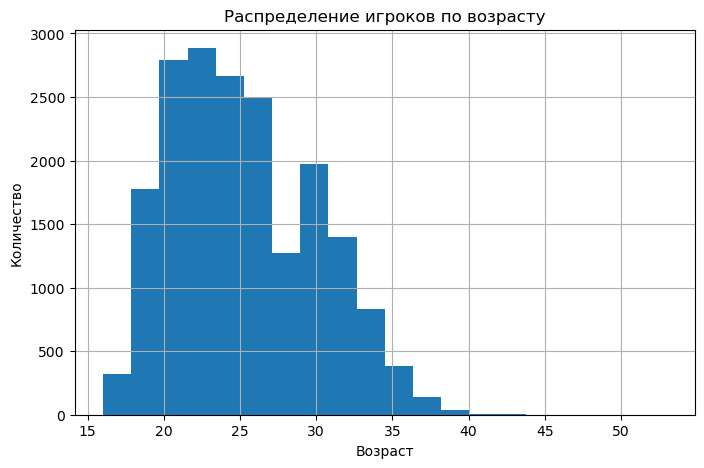

In [128]:
plt.figure(figsize=(8,5))
fifa['Age'].hist(bins=20)
plt.title("Распределение игроков по возрасту")
plt.xlabel("Возраст")
plt.ylabel("Количество")
plt.show()

Вывод:
Большинство игроков находятся в возрастном диапазоне 21–29 лет. Молодые игроки (<20) и ветераны (>35) встречаются реже. Это типично для футбольных команд, где пик карьеры приходится на середину 20-х.

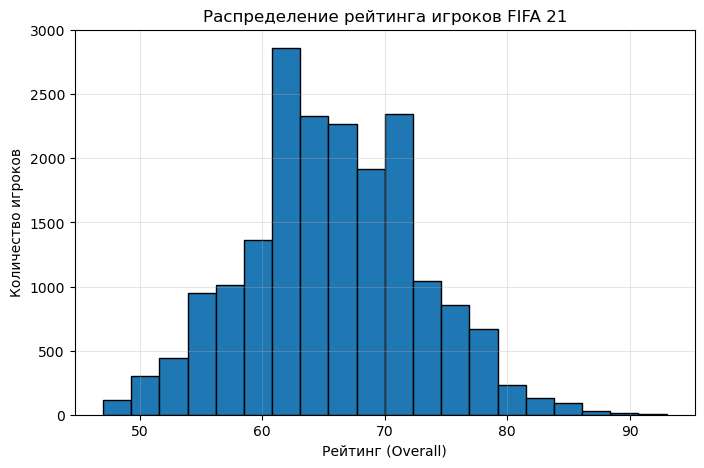

In [129]:
plt.figure(figsize=(8,5))
fifa['↓OVA'].hist(bins=20, edgecolor='black')
plt.title("Распределение рейтинга игроков FIFA 21")
plt.xlabel("Рейтинг (Overall)")
plt.ylabel("Количество игроков")
plt.grid(True, alpha=0.3)
plt.show()

Вывод:
Большинство игроков имеют рейтинг OVA между 60 и 75. Очень высокие рейтинги (>85) встречаются редко, что соответствует топ-игрокам мирового уровня.

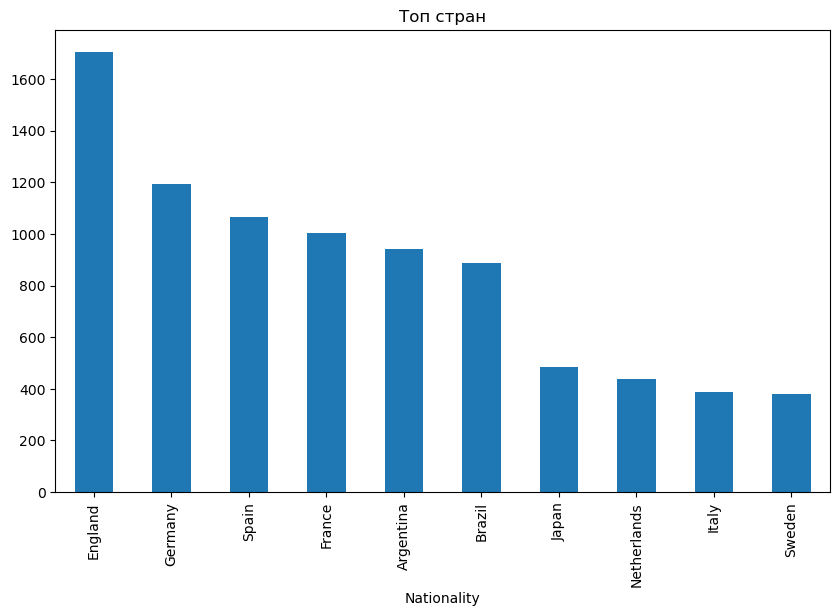

In [130]:
plt.figure(figsize=(10,6))
fifa['Nationality'].value_counts().head(10).plot(kind='bar')
plt.title("Топ стран")
plt.show()

Вывод:
В топ-10 стран по количеству игроков входят Англия, Бразилия, Испания и т.д. Эти страны традиционно дают много профессиональных футболистов.

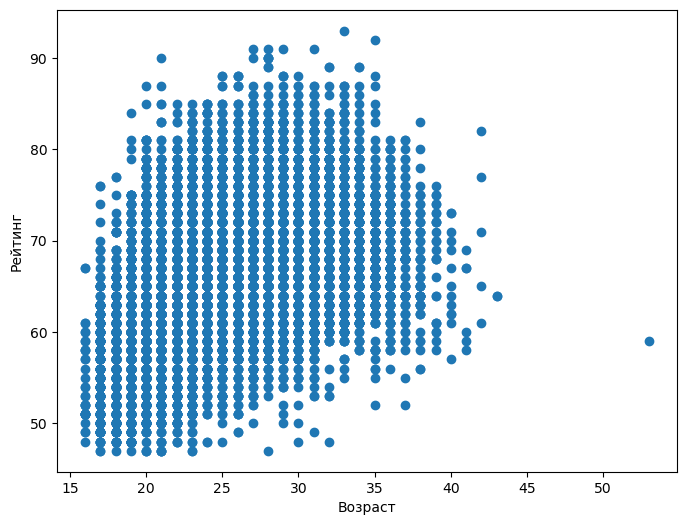

In [131]:
plt.figure(figsize=(8,6))
plt.scatter(fifa['Age'],fifa['↓OVA'])
plt.xlabel("Возраст")
plt.ylabel("Рейтинг")
plt.show()

Вывод:
Существует слабая положительная корреляция: средний рейтинг немного растет с возрастом до 25–30 лет, затем стабилизируется. Очень высокие рейтинги встречаются чаще у игроков 25–30 лет.

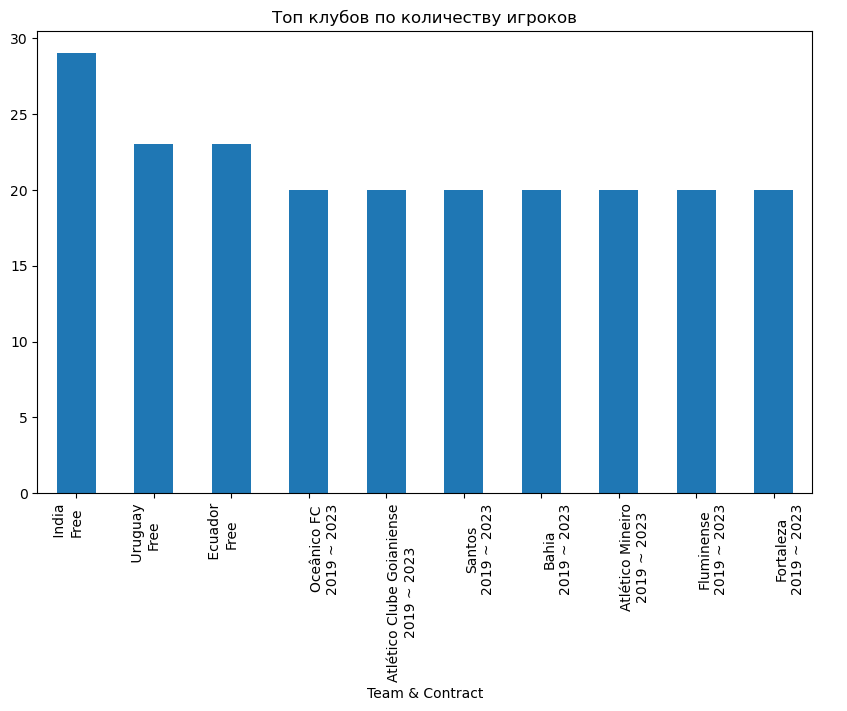

In [132]:
plt.figure(figsize=(10,6))
fifa['Team & Contract'].value_counts().head(10).plot(kind='bar')
plt.title("Топ клубов по количеству игроков")
plt.show()

Вывод:
Некоторые клубы имеют больше игроков в базе данных FIFA, что связано с их размером или популярностью в игре.

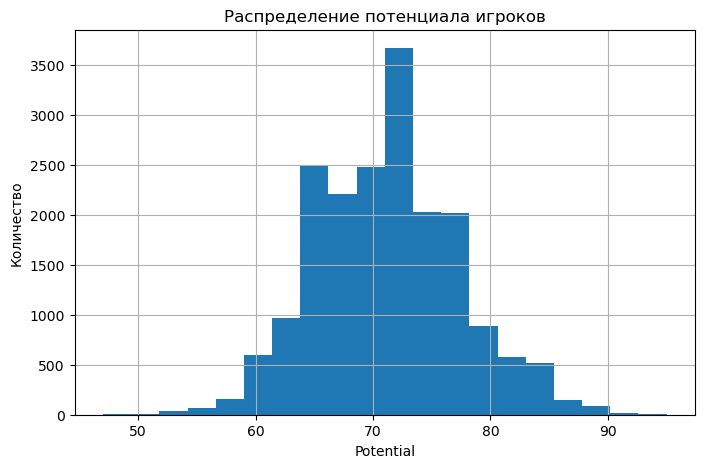

In [133]:
plt.figure(figsize=(8,5))
fifa['POT'].hist(bins=20)
plt.title("Распределение потенциала игроков")
plt.xlabel("Potential")
plt.ylabel("Количество")
plt.show()

Вывод:
Большинство игроков имеют потенциал 65–80. Очень высокие потенциалы (>85) редки и соответствуют будущим топ-игрокам.

In [134]:
features = ['Age','↓OVA','POT','Value','Wage',
            'PAC','SHO','PAS','DRI','DEF','PHY']

corr_matrix = fifa[features].corr()
corr_matrix

,Age,↓OVA,POT,Value,Wage,PAC,SHO,PAS,DRI,DEF,PHY
Age,1.000000,0.466215,-0.269453,0.046589,0.162210,-0.129714,0.265482,0.350091,0.214846,0.223743,0.445845
↓OVA,0.466215,1.000000,0.632107,0.378667,0.584363,0.266470,0.479281,0.698796,0.654751,0.362924,0.572128
POT,-0.269453,0.632107,1.000000,0.344695,0.476060,0.305862,0.275209,0.428691,0.479500,0.188011,0.204925
Value,0.046589,0.378667,0.344695,1.000000,0.603234,0.139495,0.205182,0.273024,0.270328,0.095082,0.155508
Wage,0.162210,0.584363,0.476060,0.603234,1.000000,0.163505,0.297967,0.417584,0.396455,0.187668,0.268555
PAC,-0.129714,0.266470,0.305862,0.139495,0.163505,1.000000,0.342336,0.307354,0.552004,-0.220018,-0.108348
SHO,0.265482,0.479281,0.275209,0.205182,0.297967,0.342336,1.000000,0.666149,0.769795,-0.411630,0.052287
PAS,0.350091,0.698796,0.428691,0.273024,0.417584,0.307354,0.666149,1.000000,0.829887,0.138239,0.198671
DRI,0.214846,0.654751,0.479500,0.270328,0.396455,0.552004,0.769795,0.829887,1.000000,-0.135890,0.055349
DEF,0.223743,0.362924,0.188011,0.095082,0.187668,-0.220018,-0.411630,0.138239,-0.135890,1.000000,0.532807


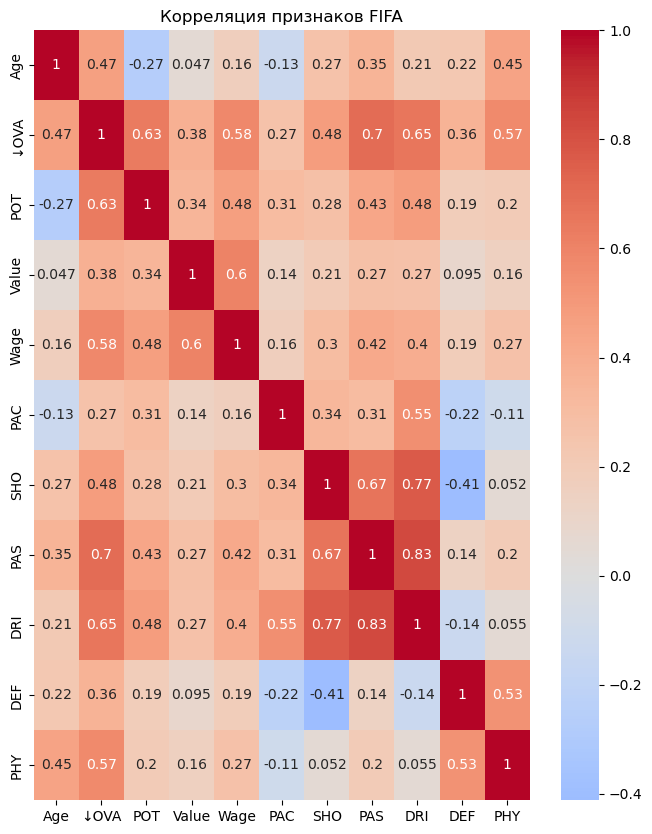

In [135]:
plt.figure(figsize=(8,10))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            center=0)

plt.title("Корреляция признаков FIFA")
plt.show()

Вывод по матрице:
- Наиболее сильная положительная корреляция наблюдается между PAS и DRI (0.83), SHO и DRI (~0.77), что логично для атакующих навыков.
- Рейтинг OVA сильно коррелирует с потенциалом (0.63) и зарплатой/ценой игрока (0.58–0.60).
- Физические показатели (PHY) умеренно коррелируют с возрастом и OVA.
- Защитные навыки (DEF) слабо связаны с атакующими, что отражает игровые роли.

## Важность признаков

In [136]:
from sklearn.ensemble import RandomForestRegressor

In [137]:
features = ['Age','POT','Value','Wage','PAC','SHO','PAS','DRI','DEF','PHY']
X = fifa[features]
y = fifa['↓OVA']

In [138]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

RandomForestRegressor(random_state=42)

In [139]:
importances = model.feature_importances_

In [140]:
feat_imp = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

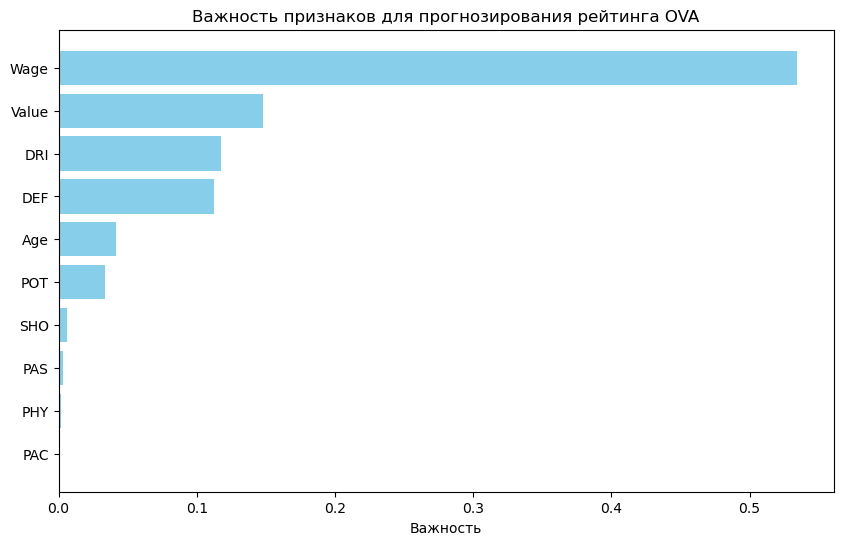

In [141]:
plt.figure(figsize=(10,6))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='skyblue')
plt.gca().invert_yaxis()
plt.title("Важность признаков для прогнозирования рейтинга OVA")
plt.xlabel("Важность")
plt.show()

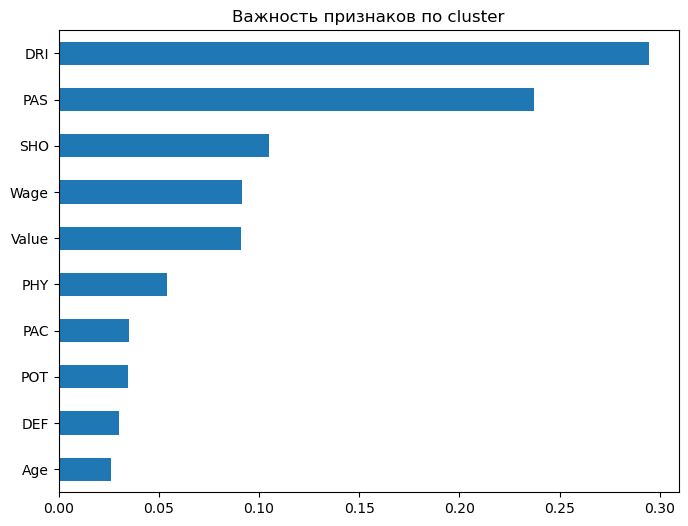

In [176]:
features = ['Age','POT','Value','Wage','PAC','SHO','PAS','DRI','DEF','PHY']
X = fifa[features]
y = fifa["cluster"]  

# Обучаем модель
model = RandomForestClassifier(random_state=42)
model.fit(X, y)

# Считаем важность
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Важность признаков по cluster")
plt.show()

## Общий вывод

Общий вывод по разведочному анализу
- Большинство игроков моложе 30 лет и имеют средний рейтинг 60–75 OVA.
- Топовые игроки и ветераны встречаются редко.
- Страны с традиционно сильными футбольными школами доминируют по количеству игроков.
- Есть очевидная зависимость между потенциальными и текущими навыками игроков.
- Корреляционный анализ показывает логичные связи между атрибутами: атакующие навыки сильнее связаны между собой, защитные — отдельно, а OVA и POT хорошо отражают рыночную ценность и зарплату.

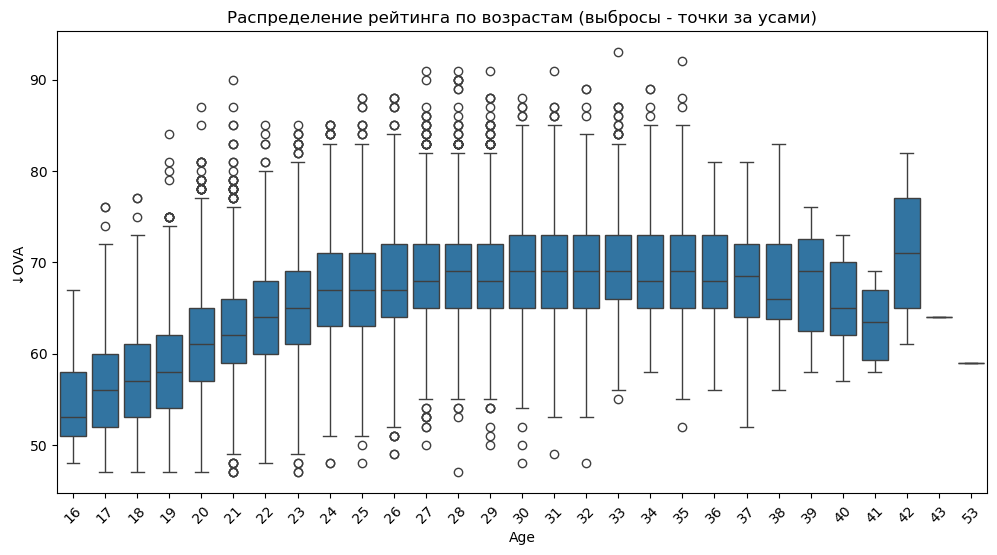

In [142]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Age', y='↓OVA', data=fifa)
plt.title('Распределение рейтинга по возрастам (выбросы - точки за усами)')
plt.xticks(rotation=45)
plt.show()

Вывод: Почему мы не удаляем выбросы из данных FIFA
В ходе анализа данных FIFA мы обнаружили выбросы (например, молодые игроки с высоким рейтингом или возрастные игроки с низким рейтингом). После изучения вопроса мы приняли решение не удалять эти выбросы по следующим причинам:
Это не ошибки, а реальные футбольные случаи
Выбросы в наших данных — это не технические ошибки или сбои, а реальные игроки:
Килиан Мбаппе (19 лет, рейтинг 87) — это не ошибка, а вундеркинд
Лионель Месси (33 года, рейтинг 93) — это не выброс, а легенда
Возрастные игроки из низших лиг — это реальность футбола
Если бы мы удалили этих игроков, мы бы потеряли важную информацию о том, как устроен футбольный мир.

## **Модуль 2. Кластеризация**

In [143]:
from sklearn.preprocessing import StandardScaler

features = ['Age','↓OVA','POT','Value','Wage',
            'PAC','SHO','PAS','DRI','DEF','PHY']

X = fifa[features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_sample = X_scaled  

## Метод локтя

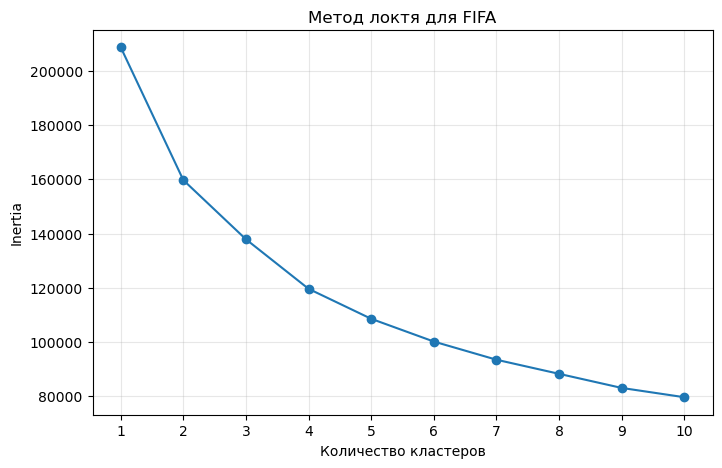

In [144]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel('Количество кластеров')
plt.ylabel('Inertia')
plt.title('Метод локтя для FIFA')
plt.xticks(range(1,11))  
plt.grid(True, alpha=0.3)
plt.show()

На графике метода локтя видно, что при K=3 происходит резкий изгиб кривой.

In [145]:
from sklearn.metrics import silhouette_score

for k in range(2,10):
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, silhouette={score:.3f}")

k=2, silhouette=0.216
k=3, silhouette=0.201
k=4, silhouette=0.203
k=5, silhouette=0.178
k=6, silhouette=0.166
k=7, silhouette=0.169
k=8, silhouette=0.168
k=9, silhouette=0.170


Мы проверили разные варианты (от 2 до 9 групп), и оценка «силуэта» показала, что именно при делении на 2 группы данные разделяются четче всего. Оценка 0.216 — это наш лучший результат; если дробить данные дальше, группы начинают «налезать» друг на друга и путаться.

## KMeans

In [146]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2,
                random_state=42,
                n_init=10)

labels_kmeans = kmeans.fit_predict(X_sample)

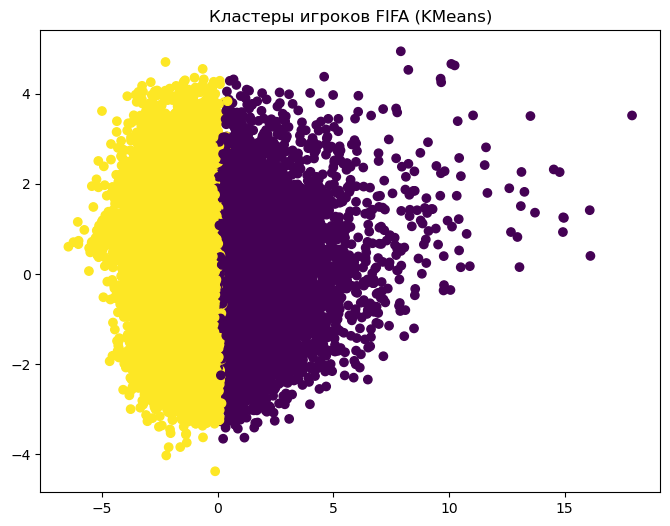

In [147]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)
plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=labels_kmeans,
    cmap='viridis'
)
plt.title("Кластеры игроков FIFA (KMeans)")
plt.show()

fifa['cluster']=labels_kmeans

## Agglomerative Clustering

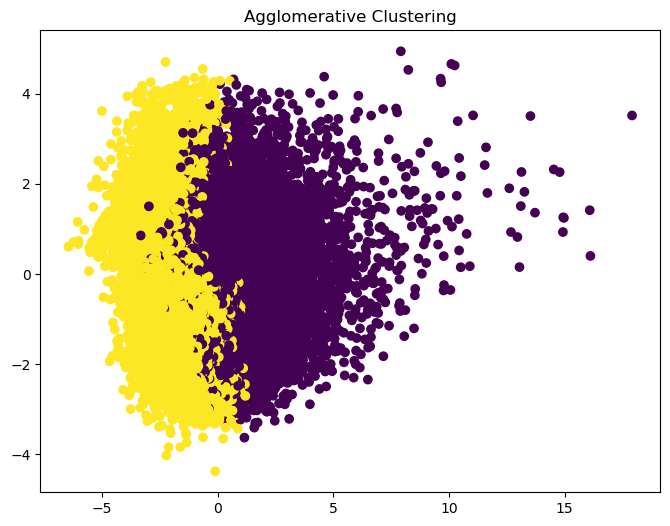

In [148]:
from sklearn.cluster import AgglomerativeClustering

agglo = AgglomerativeClustering(n_clusters=2)
clusters_agglo = agglo.fit_predict(X_sample)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters_agglo, cmap='viridis')
plt.title("Agglomerative Clustering")
plt.show() 

## DBSCAN

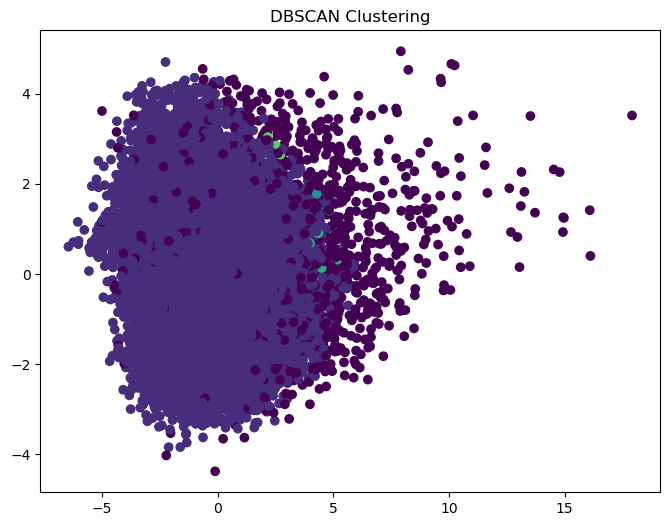

In [149]:
from sklearn.cluster import DBSCAN

# Обучаем DBSCAN
dbscan = DBSCAN(eps=1.2, min_samples=5)
clusters_dbscan = dbscan.fit_predict(X_sample)

# Визуализация через PCA
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1],
            c=clusters_dbscan,
            cmap='viridis')
plt.title("DBSCAN Clustering")
plt.show()

## Метрики кластеризации

In [150]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score

In [151]:
print("KMeans (sample):")
print("Silhouette:", silhouette_score(X_sample, labels_kmeans))
print("Calinski-Harabasz:", calinski_harabasz_score(X_sample, labels_kmeans))

KMeans (sample):
Silhouette: 0.2163707612976431
Calinski-Harabasz: 5825.247782720435


In [152]:
print("Agglomerative (sample):")
print("Silhouette:", silhouette_score(X_sample, clusters_agglo))
print("Calinski-Harabasz:", calinski_harabasz_score(X_sample, clusters_agglo))

Agglomerative (sample):
Silhouette: 0.1818883038689644
Calinski-Harabasz: 4463.877990611818


In [153]:
print("DBSCAN (sample):")
print("Silhouette:", silhouette_score(X_sample, clusters_dbscan))
print("Calinski-Harabasz:", calinski_harabasz_score(X_sample, clusters_dbscan))

DBSCAN (sample):
Silhouette: 0.09061221059924686
Calinski-Harabasz: 246.6912560784902


### Выводы по кластеризации

В работе были протестированы три алгоритма: K-Means, Agglomerative Clustering и DBSCAN. Качество оценивалось с помощью коэффициента силуэта и индекса Калински–Харабаса.

Лучшие результаты показал K-Means.

Agglomerative Clustering продемонстрировал более низкие значения метрик (0.182 и 4463.88 соответственно).
DBSCAN показал слабый результат (0.091 и 246.69), что говорит о плохой разделимости кластеров данным методом.

Таким образом, для дальнейшего анализа был выбран алгоритм K-Means.

### **Модуль 3. Описание кластеров**

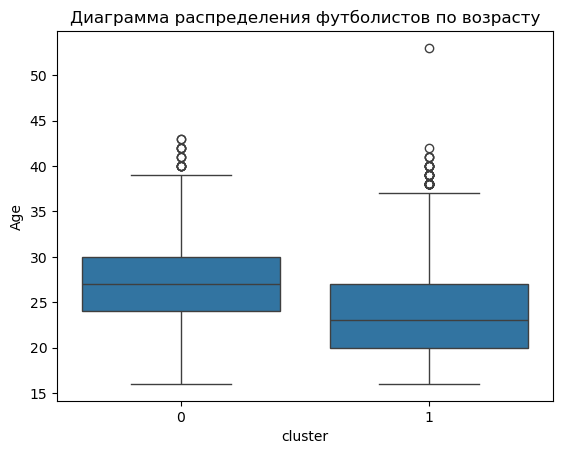

In [154]:
sns.boxplot(x="cluster", y="Age", data=fifa)
plt.title("Диаграмма распределения футболистов по возрасту")
plt.show()

Кластер 0 — Игроки с возрастом 25-30 лет

Кластер 1 — Игроки с возрастом 20-27 лет

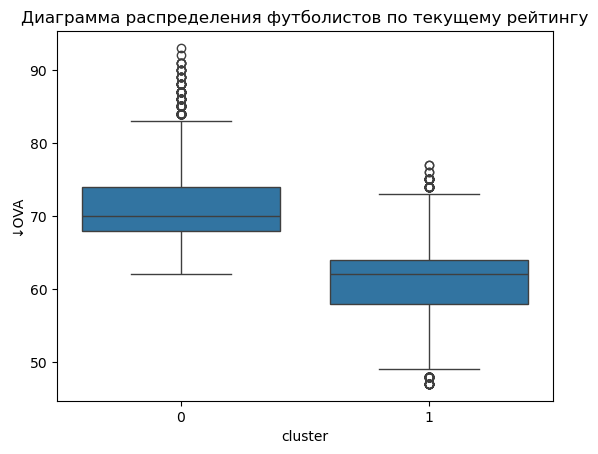

In [155]:
sns.boxplot(x="cluster", y="↓OVA", data=fifa)
plt.title("Диаграмма распределения футболистов по текущему рейтингу")
plt.show()

Кластер 0 — Игроки с высоким рейтингом (~70)

Кластер 1 — Игроки с рейтингом ниже (~60)

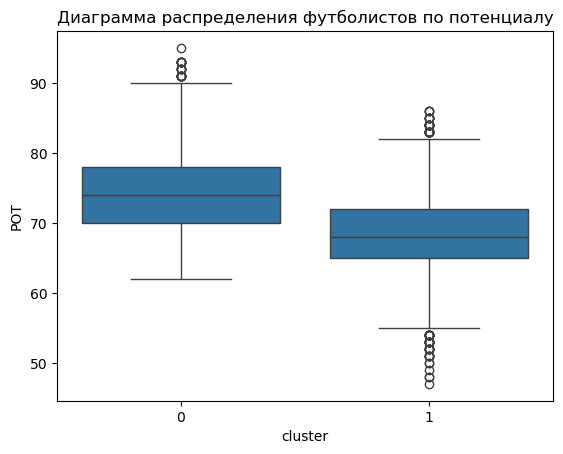

In [156]:
sns.boxplot(x="cluster", y="POT", data=fifa)
plt.title("Диаграмма распределения футболистов по потенциалу")
plt.show()

Кластер 0 — Игроки с высоким потенциалом (~70-80)

Кластер 1 — Игроки с потенциалом ниже (~60-75)

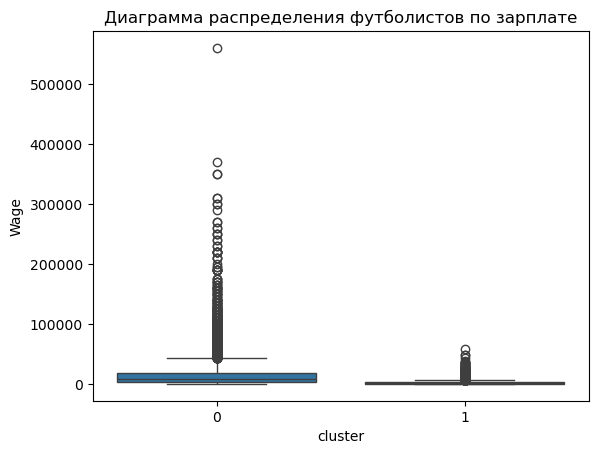

In [157]:
sns.boxplot(x="cluster", y="Wage", data=fifa)
plt.title("Диаграмма распределения футболистов по зарплате")
plt.show()

Кластер 0 — Игроки с высокой зарплатой

Кластер 1 — Игроки с зарплатой ниже


### Общий вывод:
- Кластер 0: Это опытные игроки (25–30 лет) с самым крутым рейтингом и потенциалом. Они уже всего добились, поэтому у них самые высокие зарплаты.

- Кластер 1: Это игроки помоложе (20–27 лет). У них пока ниже и рейтинг, и потенциал, поэтому и платят им меньше, чем лидерам.

### **Модуль 4. Создание модели классификации (3 метода) с метриками. Сохранить модель**

In [158]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [162]:
X = fifa.select_dtypes(include=['number']).drop("cluster", axis=1)
y = fifa["cluster"]

In [163]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Масштабирование (для SVM и KNN)

In [164]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Random Forest

In [165]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest
Accuracy: 0.9773445732349842
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      1730
           1       0.98      0.98      0.98      2066

    accuracy                           0.98      3796
   macro avg       0.98      0.98      0.98      3796
weighted avg       0.98      0.98      0.98      3796



### SVM

In [166]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(X_train_scaled, y_train)

svm_pred = svm.predict(X_test_scaled)

print("SVM")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

SVM
Accuracy: 0.9863013698630136
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1730
           1       0.99      0.99      0.99      2066

    accuracy                           0.99      3796
   macro avg       0.99      0.99      0.99      3796
weighted avg       0.99      0.99      0.99      3796



### K-ближайших соседей (KNN)

In [167]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)

print("KNN")
print("Accuracy:", accuracy_score(y_test, knn_pred))
print(classification_report(y_test, knn_pred))

KNN
Accuracy: 0.9454689146469969
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      1730
           1       0.94      0.96      0.95      2066

    accuracy                           0.95      3796
   macro avg       0.95      0.94      0.94      3796
weighted avg       0.95      0.95      0.95      3796



Сравнение моделей

In [168]:
print("Random Forest:", accuracy_score(y_test, rf_pred))
print("SVM:", accuracy_score(y_test, svm_pred))
print("KNN:", accuracy_score(y_test, knn_pred))

Random Forest: 0.9773445732349842
SVM: 0.9863013698630136
KNN: 0.9454689146469969


Мы выбрали модель SVM, потому что она показала максимальную точность (98,6%).

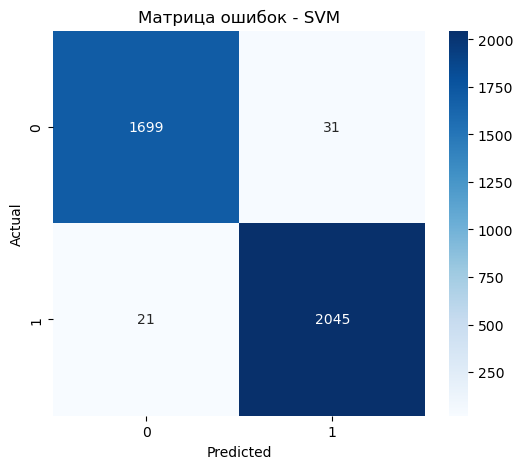

In [169]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Матрица ошибок - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

- 2045: модель правильно угадала игроков 1-го кластера.

- 1699: модель правильно угадала игроков 0-го кластера.

- 31 и 21: модель перепутала всего несколько десятков человек из почти 4000.

### Сохранение лучшей модели

In [170]:
import joblib

joblib.dump(svm, "best_cluster_classifier.pkl")
joblib.dump(scaler, "scaler.pkl") 

['scaler.pkl']

### **Дашборд**

In [106]:
fifa.to_csv('fifa.csv', index=False)

Cохранили файл, с дополнительным параметром

https://datalens.yandex/32yj8wxrn1gan

### **Общий вывод**

В результате нашей командной работы были выполнены следующие задачи:

    - Разведочный анализ данных, описание признаков датасета, определена важность признаков
    - Выполнена кластеризация 3 методами (K-Means, Агломеративная кластеризация, DBSCAN) и показана визуализация кластеров
    - Описание кластеров с визуализацией
    - Созданы модели классификации (Случайный лес, SVM, K-ближайших соседей)
    - Построен интерактивный дашборд, показывающий маркетинговый анализ.
